In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
 #Loading the dataset
df = pd.read_csv("customer_features.csv")

In [3]:
#Inital Exploration
# Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (96096, 39)


In [4]:
# First 5 rows
df.head()

,customer_unique_id,customer_city,customer_state,total_orders,repeat_customer,total_spent,average_order_value,median_order_value,minimum_order_value,maximum_order_value,spend_std_dev,total_items,average_basket_size,largest_basket,total_unique_products,total_categories,total_freight,average_freight,average_review,minimum_review,maximum_review,review_std_dev,average_installments,maximum_installments,payment_methods_used,average_delivery_days,average_delivery_delay,first_purchase,last_purchase,recency,customer_lifetime_days,customer_age,weekend_purchase_percentage,average_item_price,freight_percentage,purchase_frequency,category_diversity_ratio,low_review_orders,high_review_orders
0,df3bcbcb88d40ad1996ad1325fe8f481,praia grande,SP,1,0,160.28,160.28,160.28,160.28,160.28,NaN,2.0,2.0,2,1.0,1.0,23.00,23.00,4.0,4.0,4.0,NaN,1.0,1.0,1,7.0,-6.0,2018-06-15 15:52:21,2018-06-15 15:52:21,124,0,124,0.0,80.14,14.349888,inf,0.5,0,1
1,58704dbb44acbec0448a215ac2871320,sao paulo,SP,1,0,70.72,70.72,70.72,70.72,70.72,NaN,1.0,1.0,1,1.0,1.0,11.73,11.73,5.0,5.0,5.0,NaN,1.0,1.0,1,6.0,-11.0,2017-10-03 19:29:06,2017-10-03 19:29:06,379,0,379,0.0,70.72,16.586538,inf,1.0,0,1
2,e06358b52b33afa8edfe5a0664cfe9c5,ponte serrada,SC,1,0,60.10,60.10,60.10,60.10,60.10,NaN,1.0,1.0,1,1.0,1.0,15.10,15.10,1.0,1.0,1.0,NaN,3.0,3.0,1,17.0,-8.0,2018-02-19 12:23:34,2018-02-19 12:23:34,240,0,240,0.0,60.10,25.124792,inf,1.0,1,0
3,ee66c72bc9c41ae9de8260314b8088f4,juiz de fora,MG,1,0,247.36,247.36,247.36,247.36,247.36,NaN,2.0,2.0,2,1.0,1.0,47.38,47.38,5.0,5.0,5.0,NaN,2.0,2.0,1,6.0,-16.0,2018-06-20 19:21:04,2018-06-20 19:21:04,119,0,119,0.0,123.68,19.154269,inf,0.5,0,1
4,c2e79de2c0a7751e26564a3917f9e86d,sao paulo,SP,1,0,115.44,115.44,115.44,115.44,115.44,NaN,1.0,1.0,1,1.0,1.0,15.45,15.45,5.0,5.0,5.0,NaN,1.0,1.0,1,7.0,-16.0,2017-05-31 15:39:51,2017-05-31 15:39:51,504,0,504,0.0,115.44,13.383576,inf,1.0,0,1


In [5]:
# Column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 39 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_unique_id           96096 non-null  object 
 1   customer_city                96096 non-null  object 
 2   customer_state               96096 non-null  object 
 3   total_orders                 96096 non-null  int64  
 4   repeat_customer              96096 non-null  int64  
 5   total_spent                  96095 non-null  float64
 6   average_order_value          96095 non-null  float64
 7   median_order_value           96095 non-null  float64
 8   minimum_order_value          96095 non-null  float64
 9   maximum_order_value          96095 non-null  float64
 10  spend_std_dev                2997 non-null   float64
 11  total_items                  96096 non-null  float64
 12  average_basket_size          96096 non-null  float64
 13  largest_basket  

In [6]:
#Convert object to datetime 
date_columns = [
    "first_purchase",
    "last_purchase"
]
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

In [7]:
# Summary statistics
df.describe(include="object").T

,count,unique,top,freq
customer_unique_id,96096,96096,df3bcbcb88d40ad1996ad1325fe8f481,1
customer_city,96096,4118,sao paulo,14965
customer_state,96096,27,SP,40285


In [8]:
df.describe(include="number").T

C:\Users\swath\anaconda3\lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,count,mean,std,min,25%,50%,75%,max
total_orders,96096.0,1.034809,0.214384,1.000000,1.000000,1.000000,1.000000,1.700000e+01
repeat_customer,96096.0,0.031188,0.173825,0.000000,0.000000,0.000000,0.000000,1.000000e+00
total_spent,96095.0,165.024963,229.830686,0.000000,62.330000,106.900000,181.860000,1.366408e+04
average_order_value,96095.0,159.886924,220.708011,0.000000,61.640000,104.700000,175.905000,1.366408e+04
median_order_value,96095.0,159.853582,220.722834,0.000000,61.620000,104.630000,175.870000,1.366408e+04
minimum_order_value,96095.0,158.432950,220.249200,0.000000,60.420000,103.070000,174.360000,1.366408e+04
maximum_order_value,96095.0,161.393656,222.401962,0.000000,61.825000,105.380000,177.560000,1.366408e+04
spend_std_dev,2997.0,64.579776,110.751110,0.000000,8.315576,31.614744,75.547289,1.646887e+03
total_items,96096.0,1.231165,0.855688,0.000000,1.000000,1.000000,1.000000,7.500000e+01
average_basket_size,96096.0,1.183750,0.718911,0.000000,1.000000,1.000000,1.000000,3.800000e+01


In [9]:
# Missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)
missing.columns = ["Column", "Missing Values"]
missing.head(20)

,Column,Missing Values
0,review_std_dev,93145
1,spend_std_dev,93099
2,average_delivery_delay,2740
3,average_delivery_days,2740
4,maximum_review,716
5,average_review,716
6,minimum_review,716
7,freight_percentage,677
8,average_item_price,677
9,average_freight,676


In [10]:
# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [11]:
 #Check data types
df.dtypes

customer_unique_id                     object
customer_city                          object
customer_state                         object
total_orders                            int64
repeat_customer                         int64
total_spent                           float64
average_order_value                   float64
median_order_value                    float64
minimum_order_value                   float64
maximum_order_value                   float64
spend_std_dev                         float64
total_items                           float64
average_basket_size                   float64
largest_basket                          int64
total_unique_products                 float64
total_categories                      float64
total_freight                         float64
average_freight                       float64
average_review                        float64
minimum_review                        float64
maximum_review                        float64
review_std_dev                    

In [12]:
#View All Columns
df.columns.tolist()

['customer_unique_id',
 'customer_city',
 'customer_state',
 'total_orders',
 'repeat_customer',
 'total_spent',
 'average_order_value',
 'median_order_value',
 'minimum_order_value',
 'maximum_order_value',
 'spend_std_dev',
 'total_items',
 'average_basket_size',
 'largest_basket',
 'total_unique_products',
 'total_categories',
 'total_freight',
 'average_freight',
 'average_review',
 'minimum_review',
 'maximum_review',
 'review_std_dev',
 'average_installments',
 'maximum_installments',
 'payment_methods_used',
 'average_delivery_days',
 'average_delivery_delay',
 'first_purchase',
 'last_purchase',
 'recency',
 'customer_lifetime_days',
 'customer_age',
 'weekend_purchase_percentage',
 'average_item_price',
 'freight_percentage',
 'purchase_frequency',
 'category_diversity_ratio',
 'low_review_orders',
 'high_review_orders']

In [13]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Features :", len(num_cols))
print("Categorical Features :", len(cat_cols))

Numerical Features : 34
Categorical Features : 5


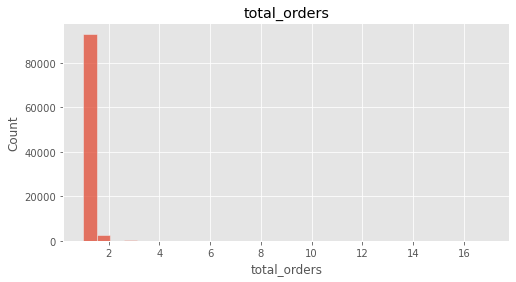

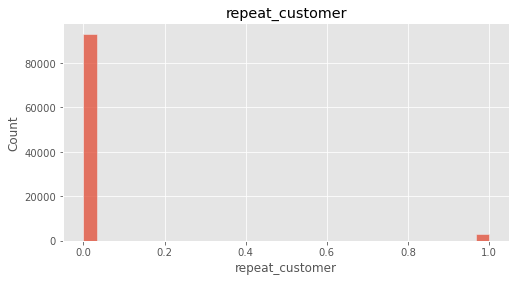

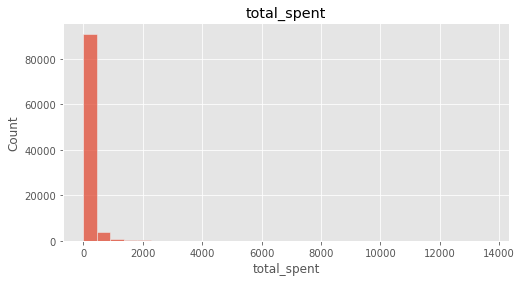

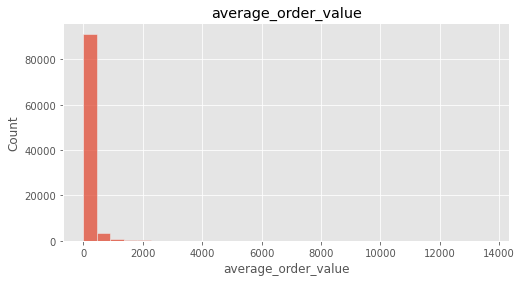

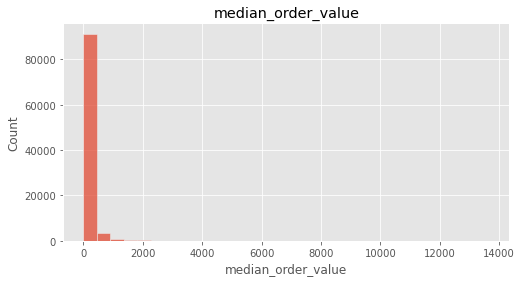

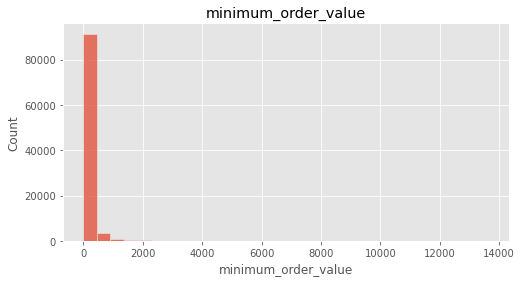

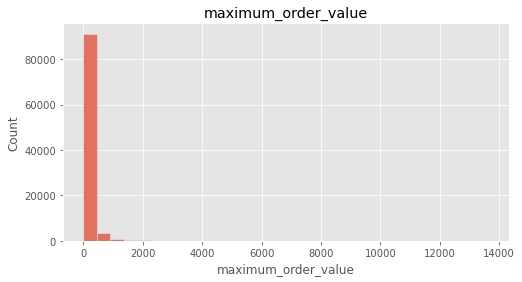

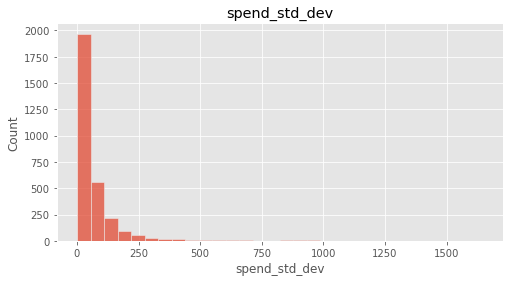

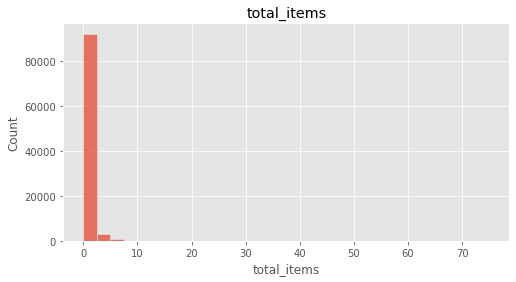

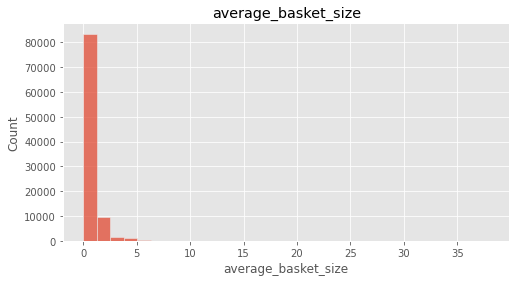

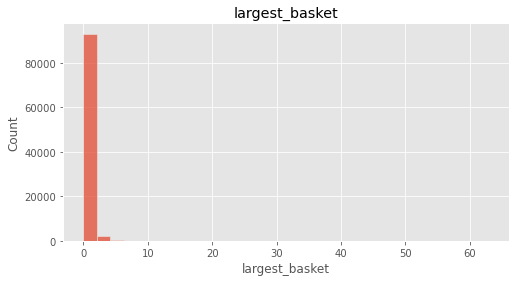

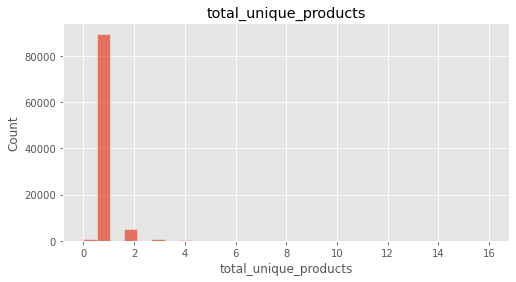

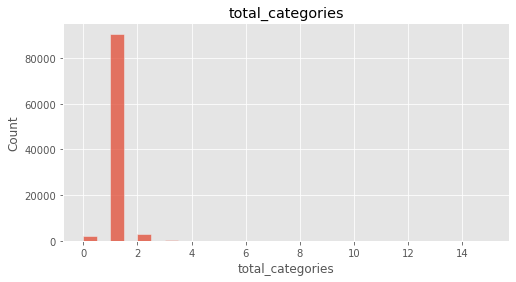

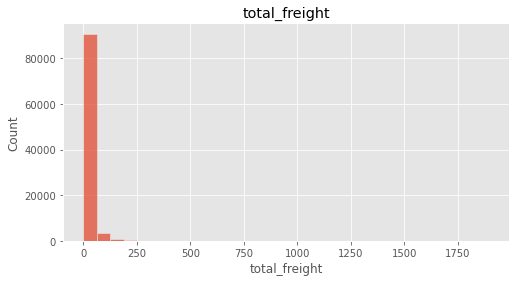

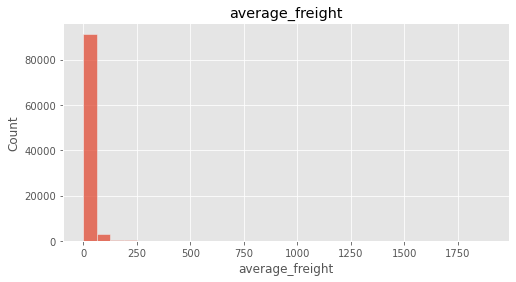

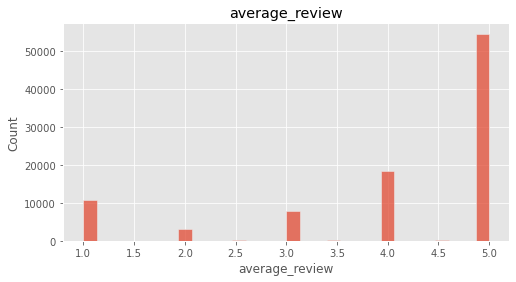

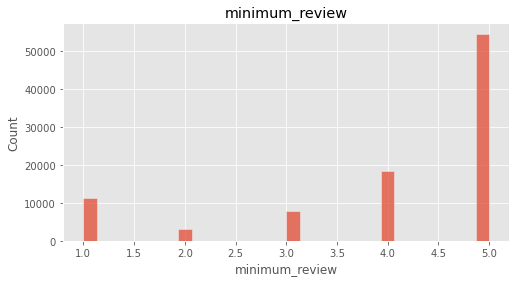

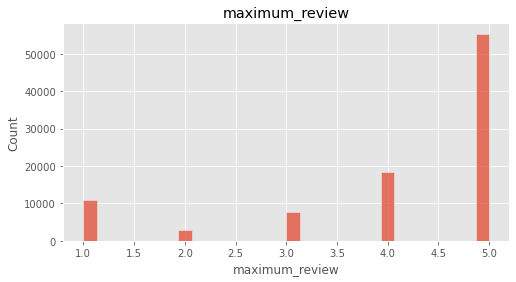

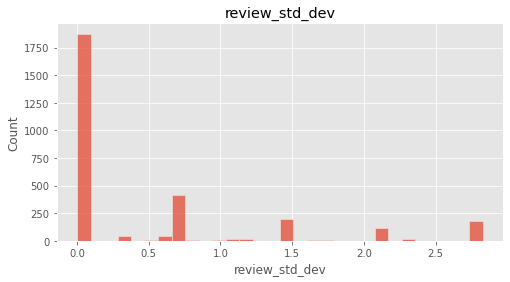

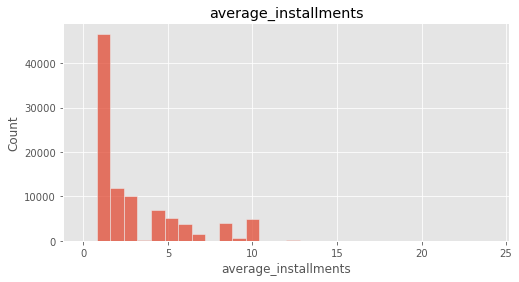

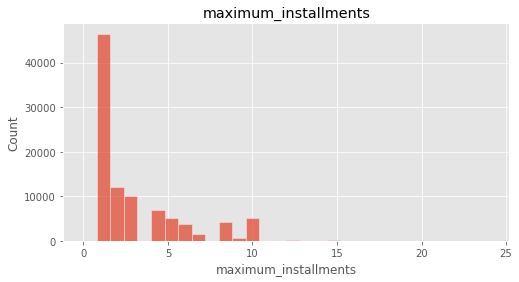

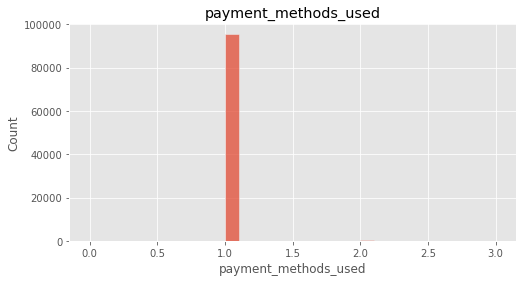

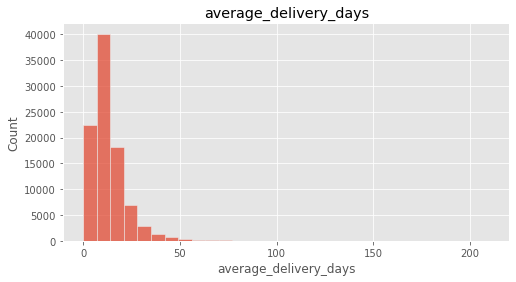

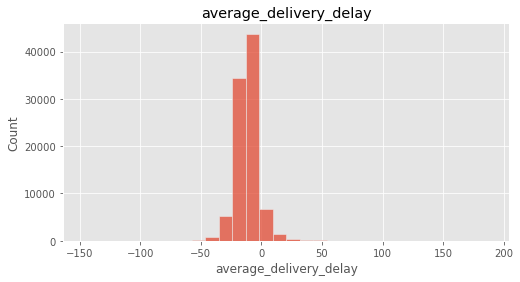

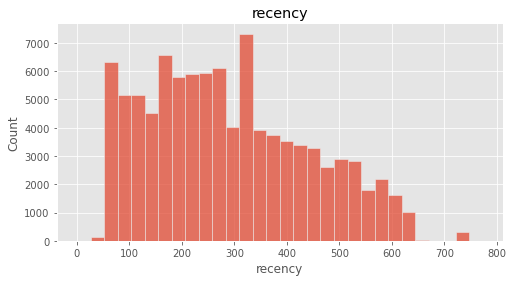

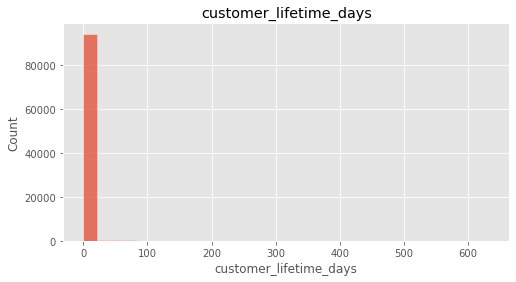

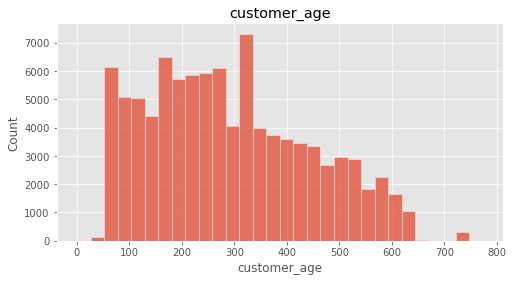

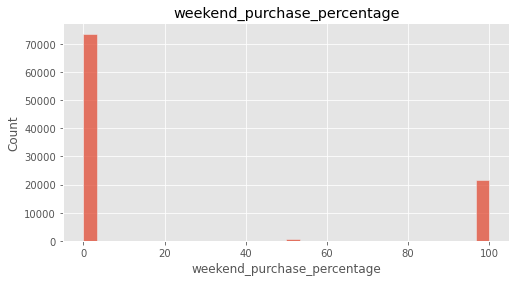

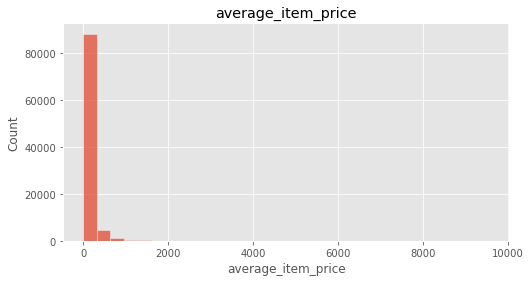

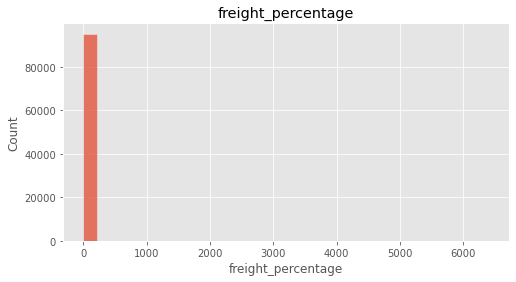

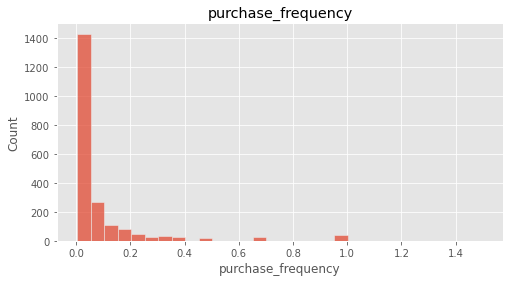

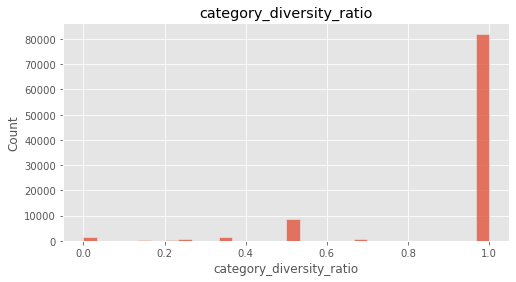

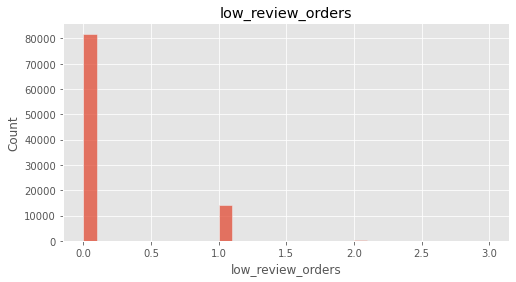

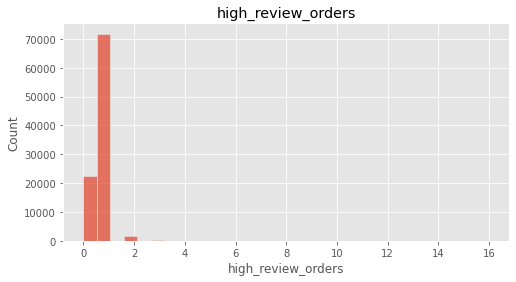

In [14]:
#Distribution of Numerical Features
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=False
    )
    plt.title(col)
    plt.show()

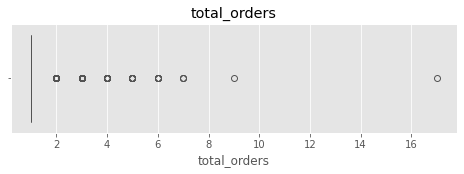

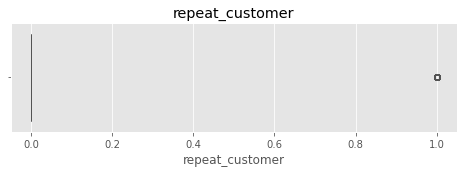

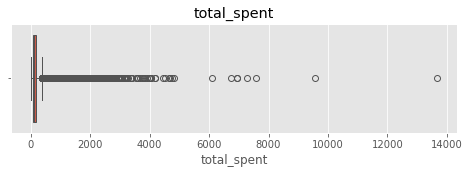

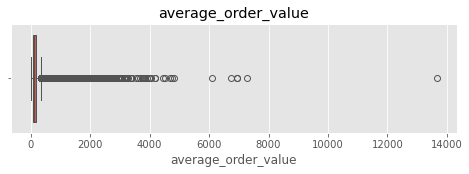

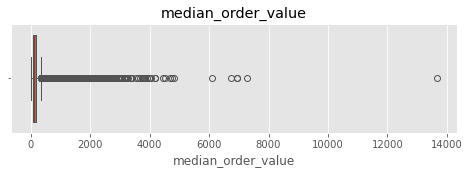

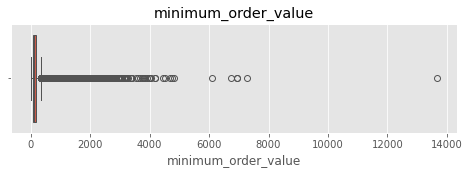

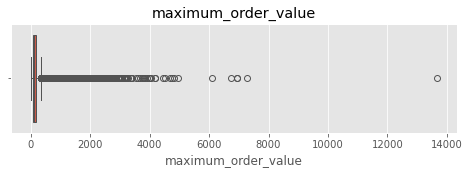

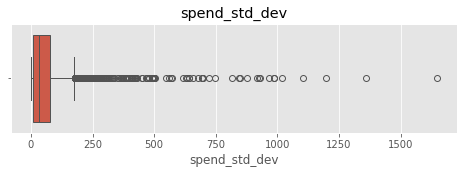

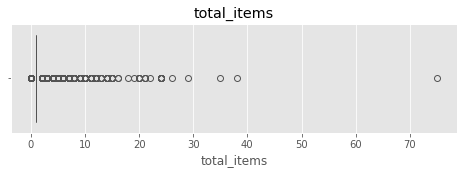

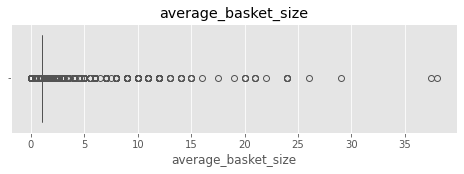

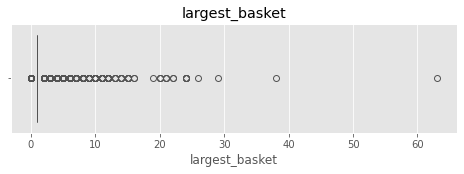

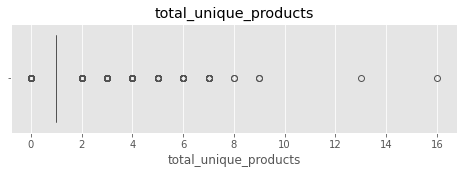

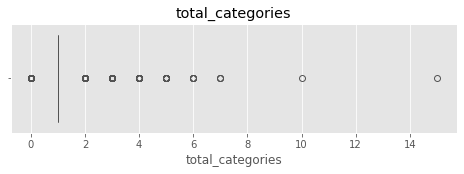

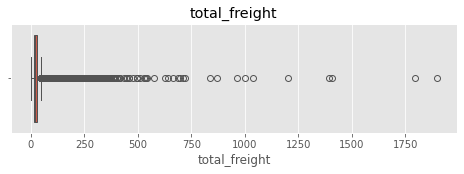

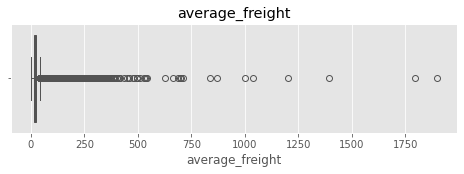

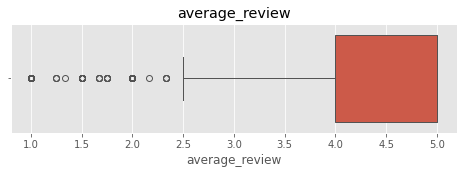

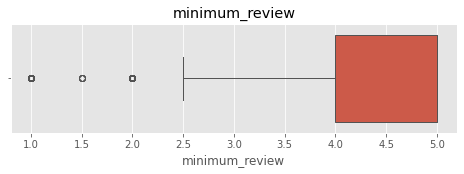

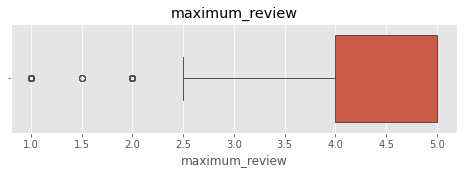

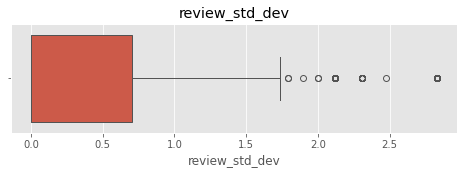

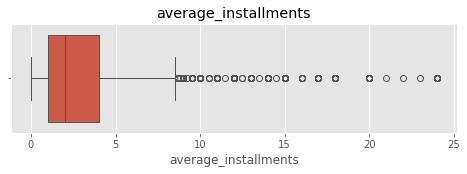

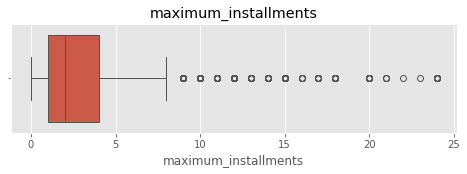

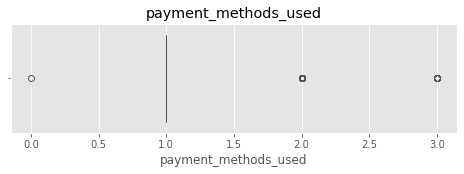

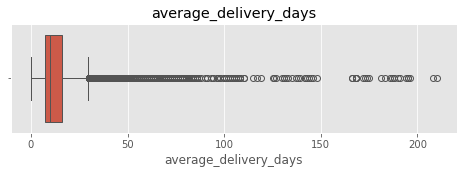

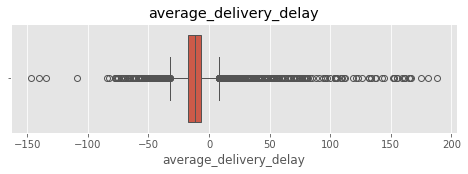

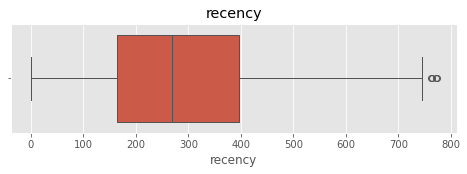

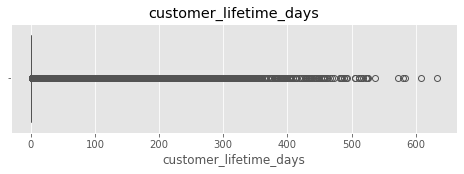

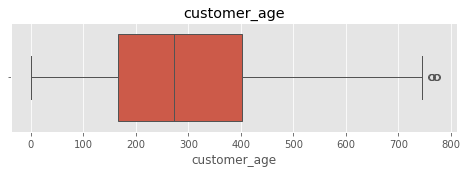

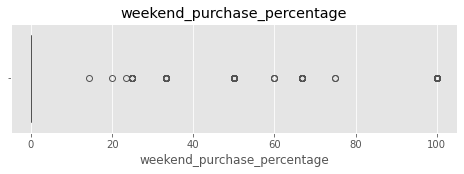

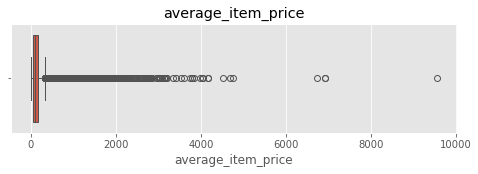

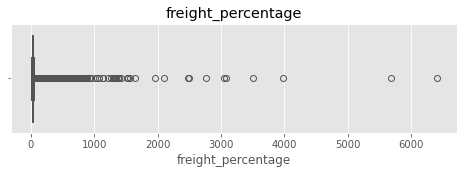

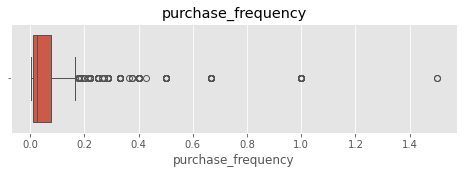

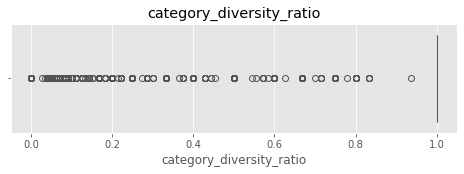

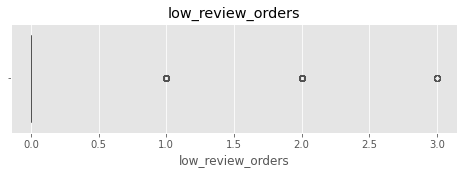

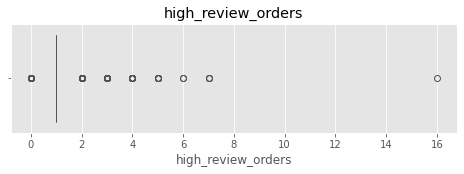

In [15]:
#Boxplots
for col in num_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(
        x=df[col]
    )
    plt.title(col)
    plt.show()

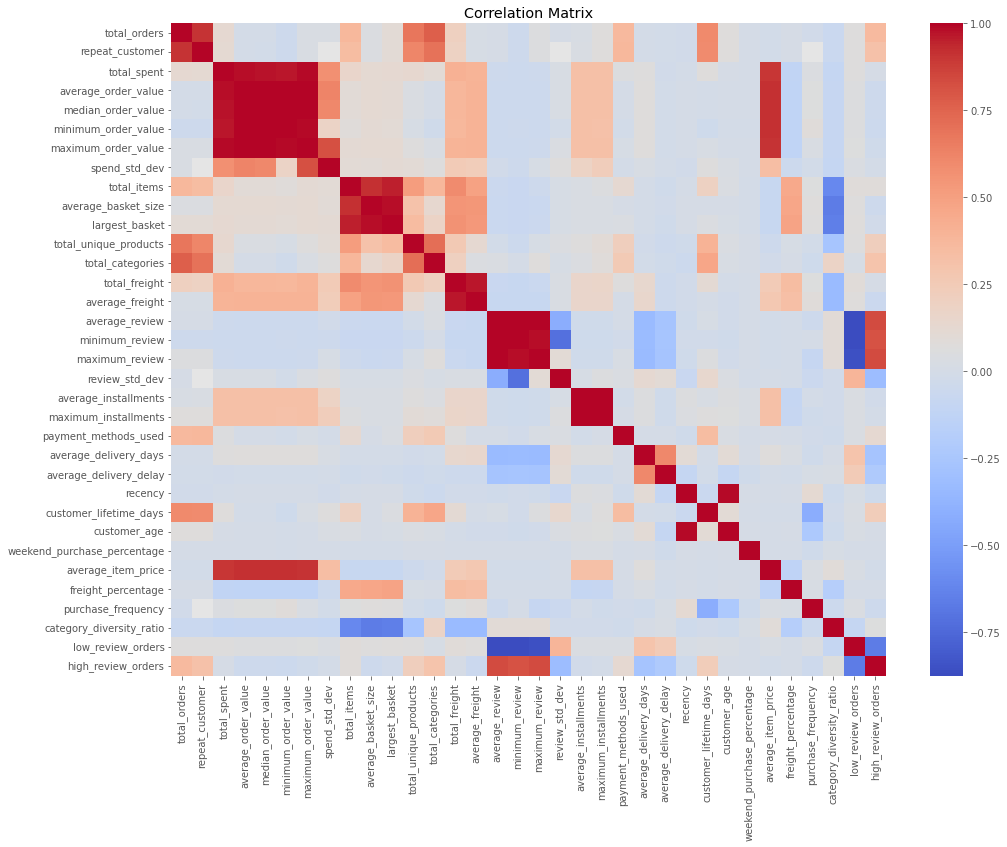

In [16]:
#Correlation Matrix
corr = df[num_cols].corr()
plt.figure(figsize=(16,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Matrix")
plt.show()

In [17]:
#Highly Correlated Variables
corr_matrix = df[num_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
high_corr = (
    upper.stack()
    .reset_index()
)
high_corr.columns = ["Variable 1","Variable 2","Correlation"]
high_corr = high_corr[
    high_corr["Correlation"]>0.80
]
high_corr.sort_values(
    "Correlation",
    ascending=False
)

,Variable 1,Variable 2,Correlation
93,average_order_value,median_order_value,0.999929
123,median_order_value,minimum_order_value,0.997324
94,average_order_value,minimum_order_value,0.997312
95,average_order_value,maximum_order_value,0.997119
124,median_order_value,maximum_order_value,0.996797
388,average_review,maximum_review,0.995966
453,average_installments,maximum_installments,0.995766
387,average_review,minimum_review,0.995671
152,minimum_order_value,maximum_order_value,0.988994
514,recency,customer_age,0.986295


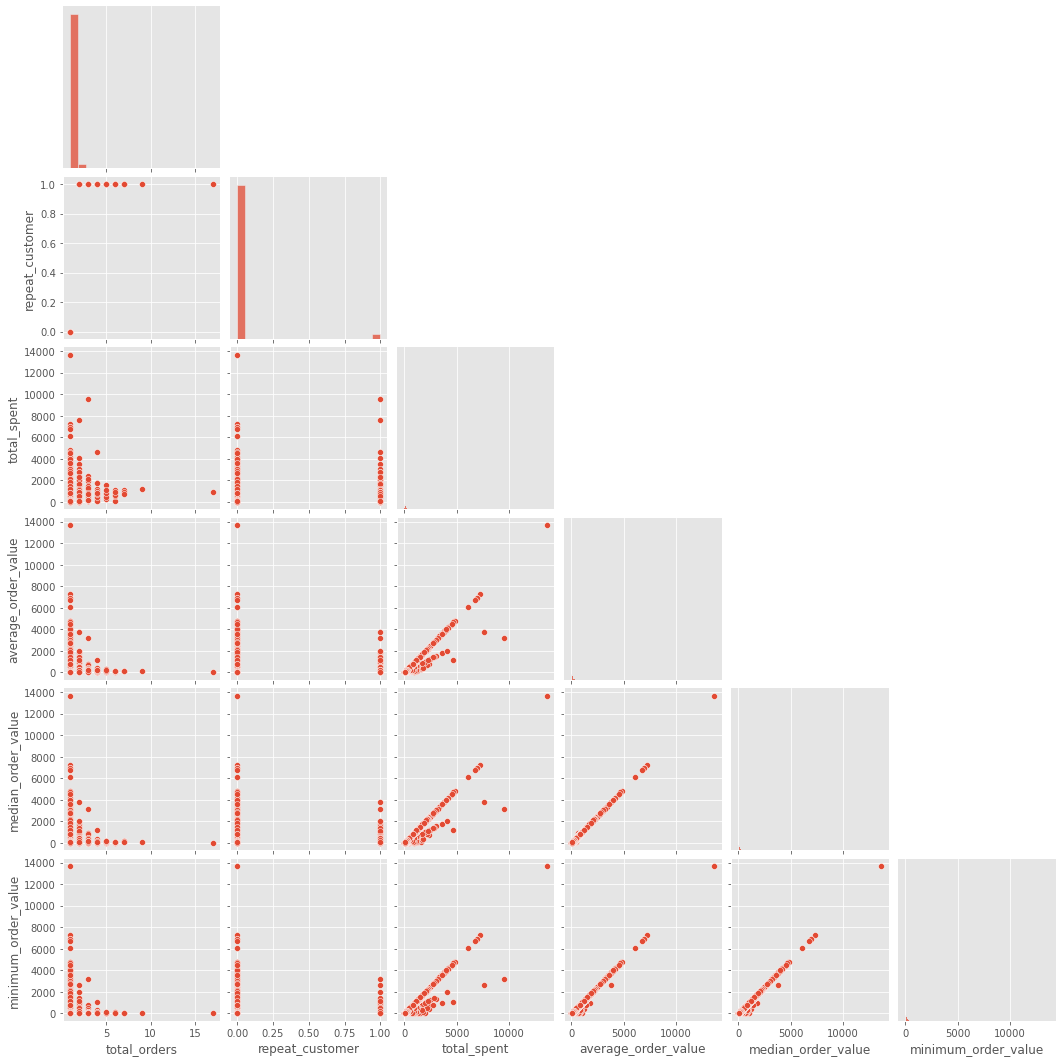

In [18]:
#Pairplot (Top Features)
top_features = num_cols[:6]
sns.pairplot(
    df[top_features],
    corner=True
)
plt.show()

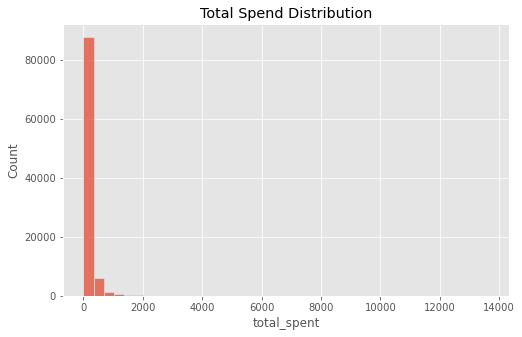

In [19]:
#Customer Spend Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df["total_spent"],
    bins=40,
    kde=False
)
plt.title("Total Spend Distribution")
plt.show()

In [20]:
max(df["total_spent"])

13664.08

In [21]:
min(df["total_spent"])

0.0

In [22]:
df["total_spent"].mean()

165.0249630053593

In [23]:
df["total_spent"].median()

106.9

In [24]:
df["total_spent"].mode()

0    77.57
Name: total_spent, dtype: float64

In [25]:
count = (df["total_spent"] > df["total_spent"].mean()).sum()
print(count)

28027


In [26]:
count = (df["total_spent"]==0).sum()
print(count)

2


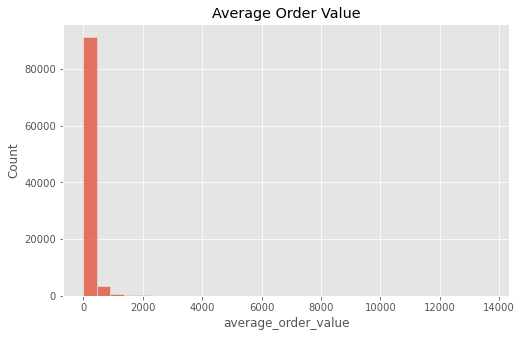

In [27]:
#Average Order Value Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["average_order_value"],
    bins=30,
    kde=False
)

plt.title("Average Order Value")

plt.show()

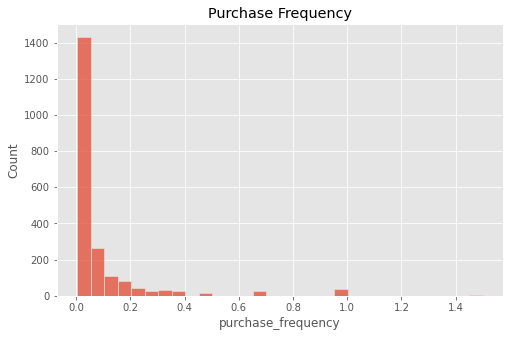

In [28]:
#Purchase Frequency
plt.figure(figsize=(8,5))

sns.histplot(
    df["purchase_frequency"],
    bins=30,
    kde=False
)

plt.title("Purchase Frequency")

plt.show()

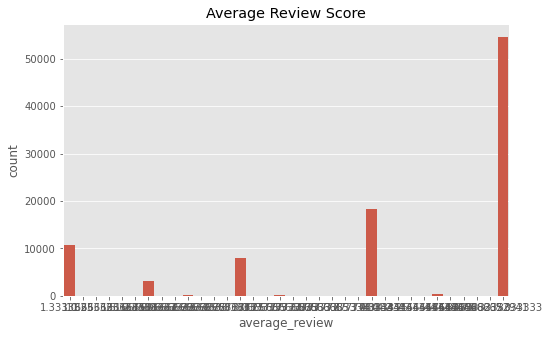

In [29]:
#Review Score Distribution
plt.figure(figsize=(8,5))
sns.countplot(
    x=df["average_review"]
)
plt.title("Average Review Score")
plt.show()

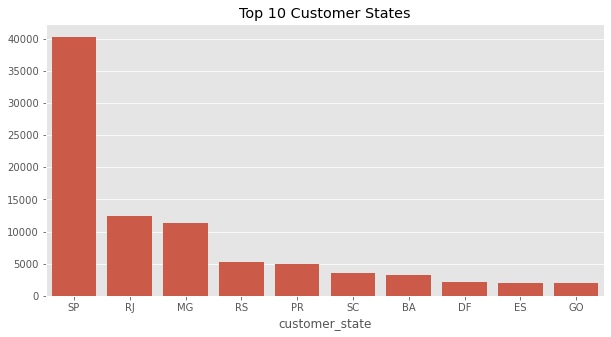

In [30]:
#Top States
top_states = (
    df["customer_state"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title("Top 10 Customer States")

plt.show()

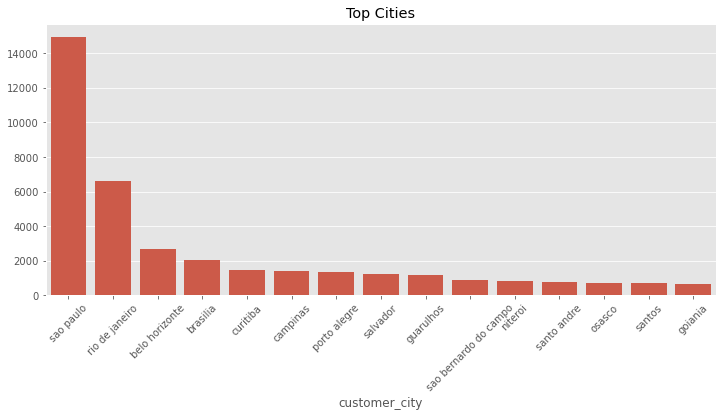

In [31]:
#Top Cities
top_city = (
    df["customer_city"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_city.index,
    y=top_city.values
)
plt.xticks(rotation=45)
plt.title("Top Cities")
plt.show()

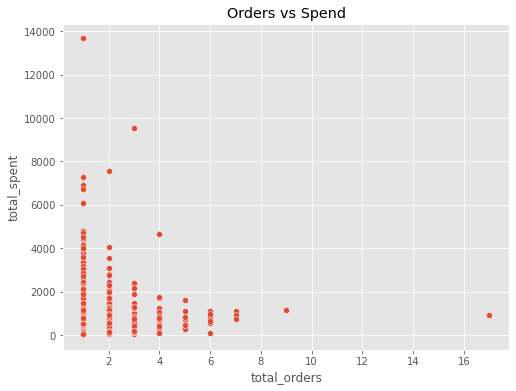

In [32]:
 #Relationship Between Spend and Orders
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="total_orders",
    y="total_spent",
    data=df
)

plt.title("Orders vs Spend")

plt.show()

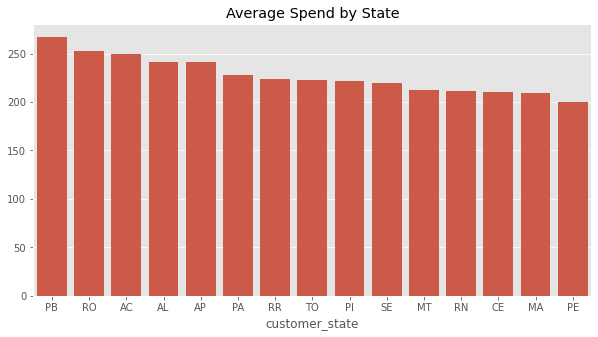

In [33]:
#Average Spend by State
state_spend = (
    df.groupby("customer_state")["total_spent"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(10,5))
sns.barplot(
    x=state_spend.index,
    y=state_spend.values
)

plt.title("Average Spend by State")
plt.show()

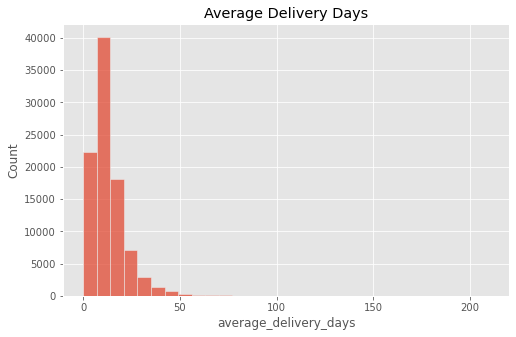

In [34]:
#Delivery Time Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["average_delivery_days"],
    bins=30,
    kde=False
)
plt.title("Average Delivery Days")
plt.show()

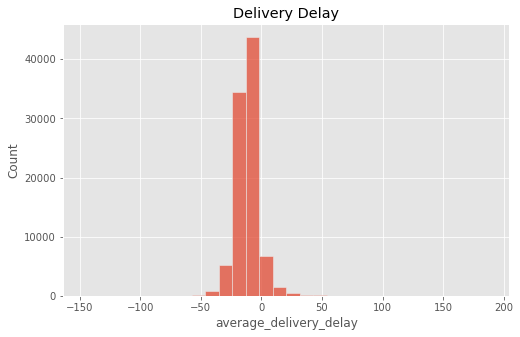

In [35]:
#Delivery Delay Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df["average_delivery_delay"],
    bins=30,
    kde=False
)
plt.title("Delivery Delay")
plt.show()

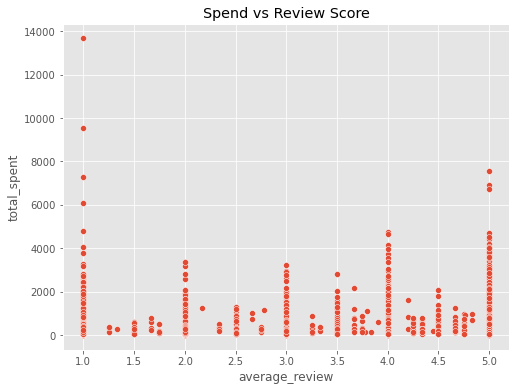

In [36]:
#Spend vs Review Score
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="average_review",
    y="total_spent"
)

plt.title("Spend vs Review Score")
plt.show()

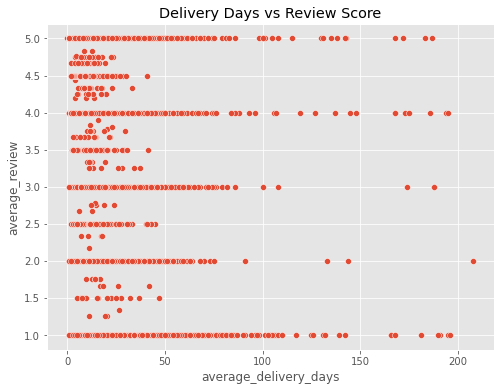

In [37]:
#Delivery Days vs Review Score
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="average_delivery_days",
    y="average_review"
)

plt.title("Delivery Days vs Review Score")
plt.show()

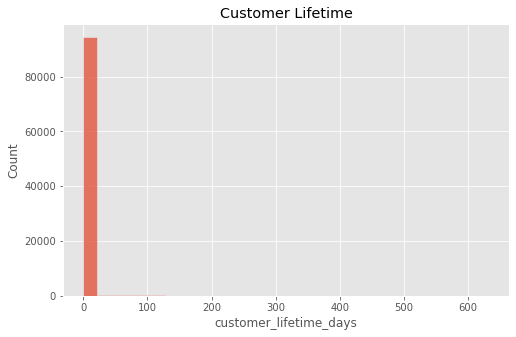

In [38]:
#Customer Lifetime (Days)
plt.figure(figsize=(8,5))
sns.histplot(
    df["customer_lifetime_days"],
    bins=30,
    kde=False
)
plt.title("Customer Lifetime")
plt.show()

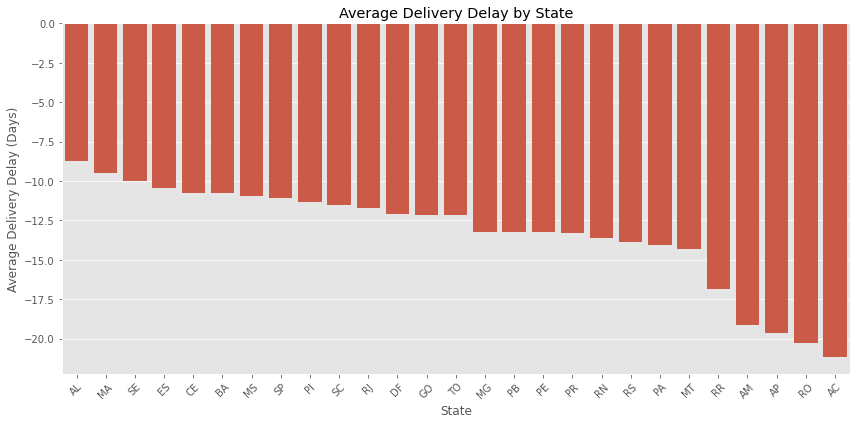

In [39]:
#Average Delivery Delay by State
state_delay = (
    df.groupby("customer_state")["average_delivery_delay"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=state_delay.index,
    y=state_delay.values
)
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Average Delivery Delay (Days)")
plt.title("Average Delivery Delay by State")
plt.tight_layout()
plt.show()

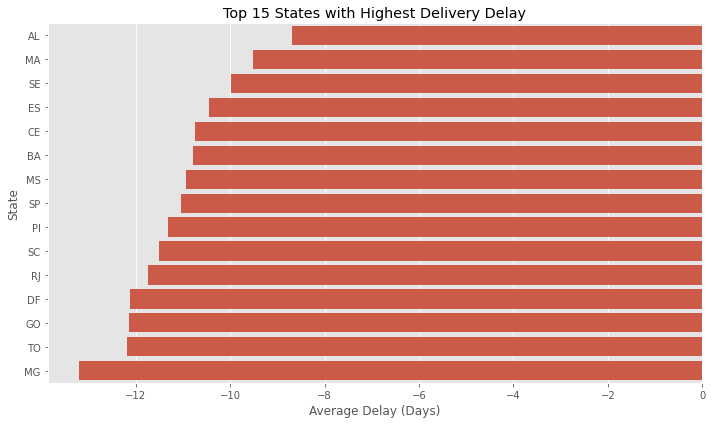

In [40]:
#Top 15 States with Highest Delivery Delay
top_state_delay = (
    df.groupby("customer_state")["average_delivery_delay"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_state_delay.values,
    y=top_state_delay.index
)
plt.xlabel("Average Delay (Days)")
plt.ylabel("State")
plt.title("Top 15 States with Highest Delivery Delay")
plt.tight_layout()
plt.show()

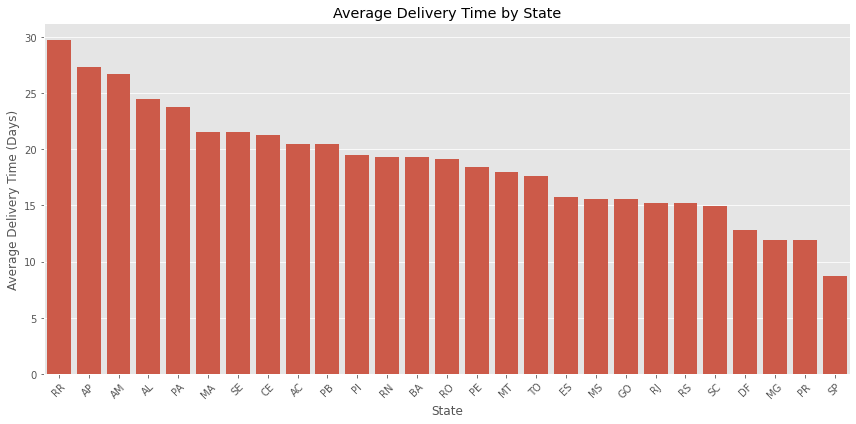

In [41]:
#Average Delivery Time by State
state_delivery = (
    df.groupby("customer_state")["average_delivery_days"]
      .mean()
      .sort_values(ascending=False)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=state_delivery.index,
    y=state_delivery.values
)
plt.xticks(rotation=45)
plt.xlabel("State")
plt.ylabel("Average Delivery Time (Days)")
plt.title("Average Delivery Time by State")
plt.tight_layout()
plt.show()

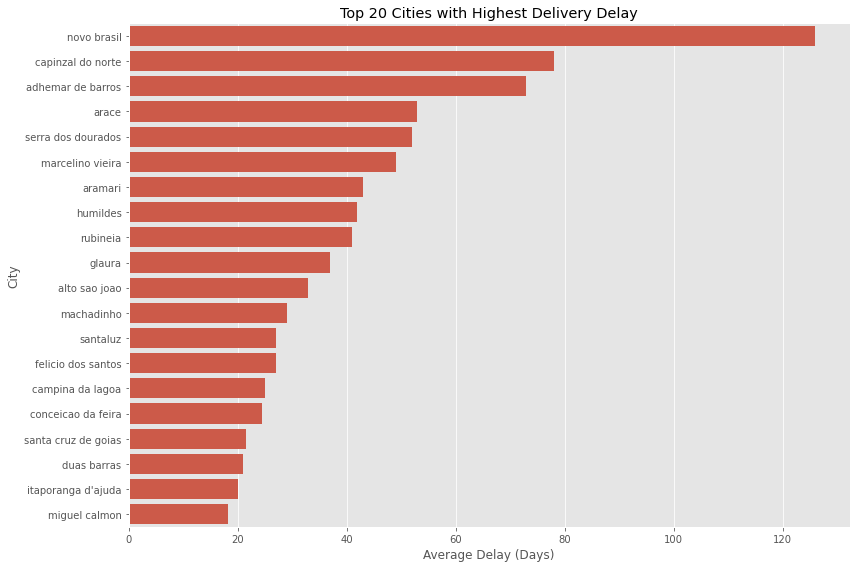

In [42]:
#Average Delivery Delay by City (Top 20 Cities)
city_delay = (
    df.groupby("customer_city")["average_delivery_delay"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)
plt.figure(figsize=(12,8))
sns.barplot(
    x=city_delay.values,
    y=city_delay.index
)
plt.xlabel("Average Delay (Days)")
plt.ylabel("City")
plt.title("Top 20 Cities with Highest Delivery Delay")
plt.tight_layout()
plt.show()

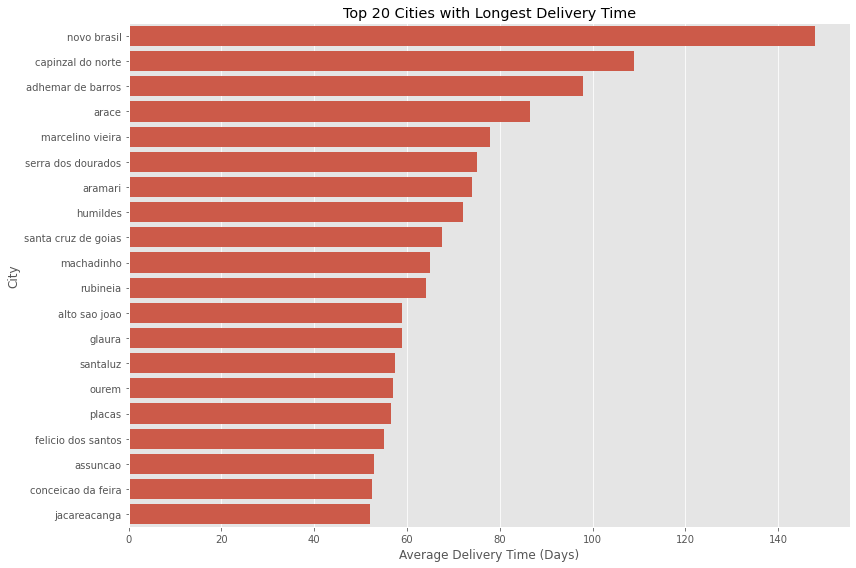

In [43]:
#Delivery Time by City (Top 20)
city_delivery = (
    df.groupby("customer_city")["average_delivery_days"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)
plt.figure(figsize=(12,8))
sns.barplot(
    x=city_delivery.values,
    y=city_delivery.index
)
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("City")
plt.title("Top 20 Cities with Longest Delivery Time")
plt.tight_layout()
plt.show()

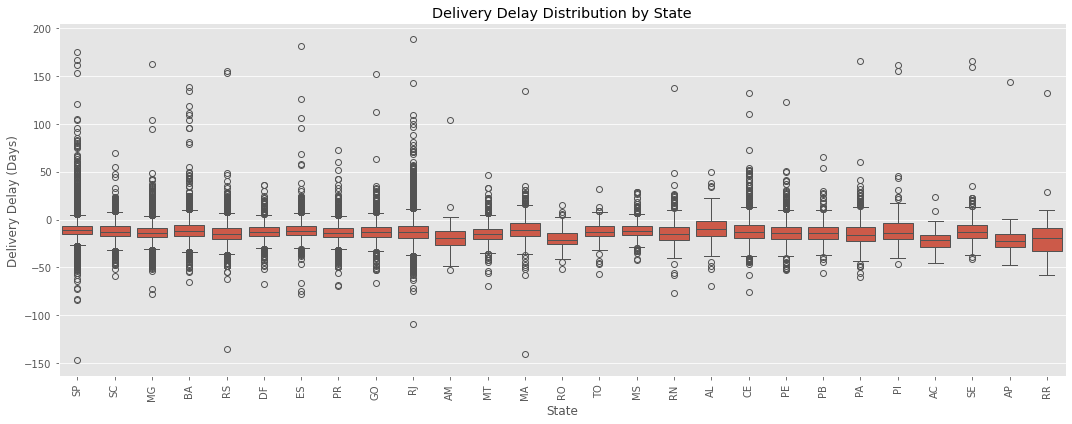

In [44]:
#Distribution of Delivery Delay Across States (Boxplot)
plt.figure(figsize=(15,6))
sns.boxplot(
    data=df,
    x="customer_state",
    y="average_delivery_delay"
)
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Delivery Delay (Days)")
plt.title("Delivery Delay Distribution by State")
plt.tight_layout()
plt.show()

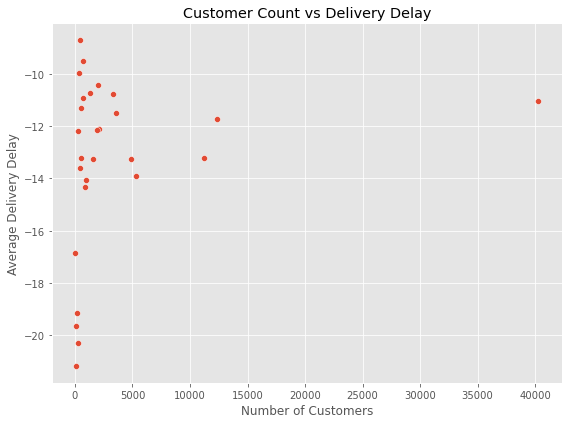

In [45]:
#Average Delay vs Number of Customers
state_summary = (
    df.groupby("customer_state")
      .agg(
          avg_delay=("average_delivery_delay","mean"),
          customers=("customer_unique_id","count")
      )
      .reset_index()
)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=state_summary,
    x="customers",
    y="avg_delay"
)
plt.xlabel("Number of Customers")
plt.ylabel("Average Delivery Delay")
plt.title("Customer Count vs Delivery Delay")
plt.tight_layout()
plt.show()

In [46]:
#Skewness
skew = df[num_cols].skew()
skew.sort_values()

C:\Users\swath\anaconda3\lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


category_diversity_ratio       -2.555925
maximum_review                 -1.381020
average_review                 -1.361689
minimum_review                 -1.343016
high_review_orders              0.014584
customer_age                    0.427490
recency                         0.445452
weekend_purchase_percentage     1.285537
maximum_installments            1.594304
average_installments            1.603625
review_std_dev                  1.683805
average_delivery_delay          2.107209
low_review_orders               2.115963
average_delivery_days           3.879295
total_categories                4.749358
spend_std_dev                   5.348474
repeat_customer                 5.394179
total_unique_products           6.580236
average_item_price              8.360182
maximum_order_value             9.178525
median_order_value              9.280611
average_order_value             9.281577
minimum_order_value             9.311043
total_spent                     9.555519
average_basket_s

In [47]:
#Kurtosis
kurt = df[num_cols].kurt()
kurt.sort_values()

C:\Users\swath\anaconda3\lib\site-packages\pandas\core\nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


customer_age                     -0.679134
recency                          -0.654696
weekend_purchase_percentage      -0.333232
minimum_review                    0.443981
average_review                    0.515323
maximum_review                    0.563294
review_std_dev                    1.759697
maximum_installments              2.339273
average_installments              2.395403
low_review_orders                 3.110955
category_diversity_ratio          5.660862
high_review_orders               14.105087
repeat_customer                  27.097728
average_delivery_delay           29.076292
average_delivery_days            40.263618
spend_std_dev                    43.413565
total_unique_products           105.588255
total_categories                120.560949
average_item_price              158.287081
customer_lifetime_days          170.447918
maximum_order_value             236.863645
median_order_value              242.493131
average_order_value             242.551262
minimum_ord

In [48]:
#Outlier Detection
outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col,outliers])
outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature","Outliers"]
)
outlier_df.sort_values(
    "Outliers",
    ascending=False
)

C:\Users\swath\anaconda3\lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\swath\anaconda3\lib\site-packages\numpy\lib\function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


,Feature,Outliers
33,high_review_orders,24329
27,weekend_purchase_percentage,22427
8,total_items,15078
32,low_review_orders,14228
16,minimum_review,14228
15,average_review,13863
17,maximum_review,13792
31,category_diversity_ratio,13316
9,average_basket_size,13313
10,largest_basket,13257


In [49]:
import numpy as np
df.replace([np.inf, -np.inf], np.nan, inplace=True)

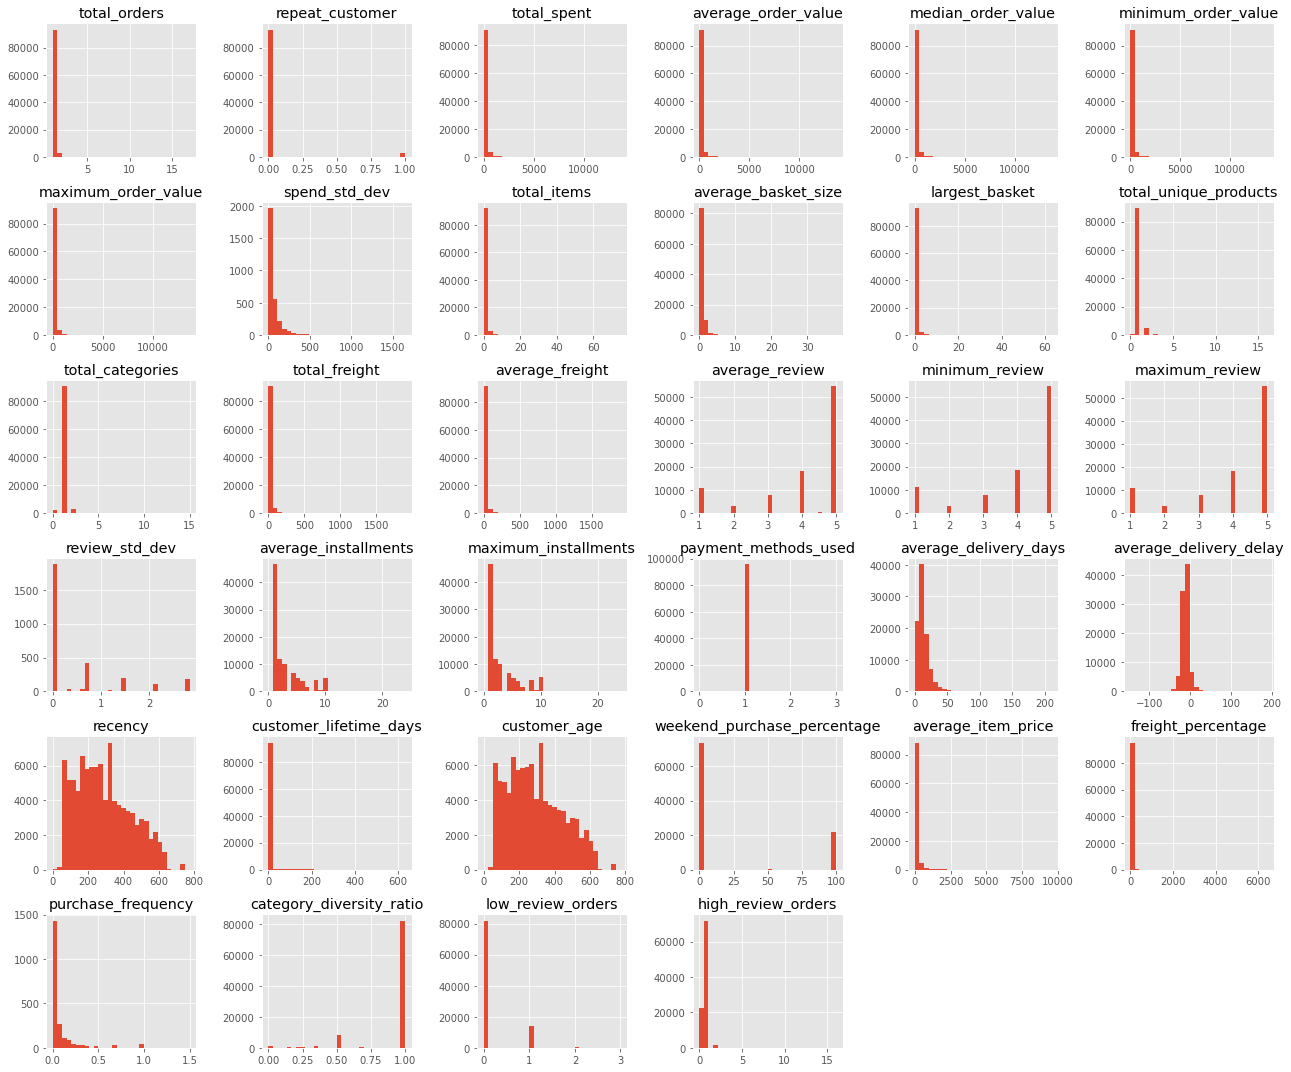

In [50]:
#Feature Distributions Together
df[num_cols].hist(
    figsize=(18,15),
    bins=30
)
plt.tight_layout()
plt.show()

#### Exploratory Data Analysis Summary & Key Findings

##### 1. Dataset Overview
The customer-level analytical dataset contains 96,096 customers and 39 features.

Features include customer demographics, purchasing behaviour, basket characteristics, payment behaviour, review metrics, delivery performance, and customer lifetime measures.
The dataset consists of:
1) 34 numerical variables
2) 5 categorical variables

No duplicate customer records were identified, confirming that each row represents a unique customer.

###### 2. Data Quality Assessment

Overall data quality is high, with most variables being complete.

Missing Values

Missing values are concentrated in a small number of engineered features.These missing values are structural rather than random, meaning they arise from customer behaviour rather than data collection errors.

For example, In the feature *average_delivery_days*, Missing where delivery information is unavailable or the order was not delivered.

##### 3. Feature Distribution

The numerical distributions reveal several common characteristics of customer transaction data.

****Spending Variables****
Spending-related variables exhibit positive (right) skewness.
Most customers have relatively low spending levels.
A small number of customers contribute substantially higher spending amounts.
This suggests a concentration of revenue among a limited segment of customers.

**Order Behaviour**

The distribution of:

Total orders
Basket size
Purchase frequency
indicates that:
1) Most customers place only a few orders.
2) A smaller segment consists of frequent purchasers.
3) Customer purchasing behaviour is therefore highly heterogeneous.

**Delivery Variables**

Delivery-related metrics also display right-skewed distributions.

Most customers receive their orders within a relatively short period, while a small number experience substantially longer delivery times or delays.

This indicates occasional operational inefficiencies rather than consistently poor logistics performance.

 **Review Variables**

Review-related features are concentrated toward higher ratings.

This suggests that:

Customer satisfaction is generally positive.
Lower ratings occur relatively infrequently.

##### 4. Outlier Analysis

Boxplots reveal outliers across several variables, particularly:

Total spending
Order value
Basket size
Customer lifetime
Delivery duration

These observations likely represent genuine customer behaviour rather than erroneous data.

Examples include:

High-value customers
Bulk purchasers
Long-term customers
Customers experiencing unusually long delivery times

Since these observations provide meaningful business information, they should be retained for subsequent analyses.

##### 5. Correlation Analysis

The correlation matrix highlights several strong relationships among engineered features.

Notable observations include:

Average order value and median order value exhibit an almost perfect positive correlation (0.9999).
Minimum, median, average, and maximum order values are all highly correlated.
These variables describe similar aspects of customer spending behaviour.

This indicates the presence of highly related features, which should be considered during feature selection for predictive modelling or clustering.

The strong correlations are expected because many variables were engineered from the same purchase history.

##### 6. Geographic Distribution

Customer distribution across states and cities is uneven.

EDA indicates that:

Some states contain substantially larger customer populations.
Customer activity is concentrated in a limited number of cities.
Geographic imbalance reflects differences in market penetration across regions.

These regional differences may influence customer behaviour and delivery performance in later analyses.

##### 7. Customer Spending Behaviour

The spending distributions suggest several important behavioural characteristics.

Customer spending varies considerably across individuals.
Most customers contribute relatively small amounts.
A minority of customers account for disproportionately high spending.
Average order values are considerably more stable than total spending, indicating that purchase frequency contributes significantly to differences in customer value.

##### 8. Delivery Performance

Delivery metrics indicate variation across customers.

The analysis shows:

Most deliveries occur within expected timeframes.
Some customers experience substantial delivery delays.
Delivery duration exhibits greater variability than average customer spending.

Regional delivery comparisons introduced earlier in the notebook suggest that delivery performance differs across states and cities.

##### 9. Customer Lifetime

Customer lifetime displays noticeable variation.

The distribution indicates that:

Some customers make only short-term purchases.
Others continue purchasing over much longer periods.

This variability provides a useful basis for future customer segmentation and retention analyses.

##### 10. Overall Characteristics of the Dataset

The exploratory analysis suggests that the dataset exhibits several characteristics commonly observed in e-commerce customer data:

Right-skewed spending distributions.
Presence of genuine high-value customer outliers.
Strong correlations among engineered spending variables.
High overall data completeness.
Behavioural diversity across customers.
Geographic variation in customer distribution.
Variation in delivery performance.
Predominantly positive customer review patterns.

#### Overall EDA Conclusions

The exploratory analysis confirms that the engineered customer dataset is well suited for advanced customer analytics. The data is clean, with no duplicate records and only expected structural missing values. Customer behaviour is highly heterogeneous, with considerable variation in spending, purchasing frequency, customer lifetime, and delivery experience. Spending and order-related variables exhibit right-skewed distributions and contain genuine high-value outliers that represent important customer segments rather than data quality issues. Several engineered monetary variables are strongly correlated, reflecting similar aspects of purchasing behaviour and indicating that feature selection may be required for modelling tasks. Geographic analyses reveal an uneven customer distribution across states and cities, while delivery metrics show variability across regions. Overall, the EDA provides a strong understanding of the dataset's structure and characteristics and establishes a solid foundation for the subsequent notebooks on customer segmentation, business question analysis, and predictive modelling.